# Basic Music Recommender Implementation
We will be using a content-based implementation as we are missing the user "listening history". This means that we will focus on "similarity" between songs, and then recommend a new song based on how we define "similar" songs.

## Load the dataset

In [22]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

DATA_PATH = "master_spotify_songs.csv"

raw = pd.read_csv(DATA_PATH)
print("Raw shape:", raw.shape)

# set the features of interest
FEATURES = ["danceability", "energy", "valence", "acousticness", "bpm"]

songs = raw[~raw["text_damaged"]]                     # drop garbled titles/artists
songs = songs.dropna(subset=FEATURES)                 # keep songs with audio features
songs = songs.drop_duplicates(subset=["title", "primary_artist"])
songs = songs[["song_id", "title", "primary_artist", "release_year"] + FEATURES].reset_index(drop=True)

print("Usable songs:", len(songs))
songs.head()

Raw shape: (4766, 111)
Usable songs: 914


,song_id,title,primary_artist,release_year,danceability,energy,valence,acousticness,bpm
0,71,10 Things I Hate About You,Leah Kate,2022,0.54,0.79,0.45,0.01,154.0
1,78,2055,Sleepy hallow,2021,0.78,0.52,0.65,0.46,161.0
2,82,212,Mainstreet,2022,0.79,0.52,0.86,0.66,154.0
3,92,25k jacket (feat. Lil Baby),Gunna,2022,0.90,0.54,0.74,0.16,115.0
4,93,295,Sidhu Moose Wala,2021,0.68,0.76,0.54,0.21,90.0


## Brief analysis of features

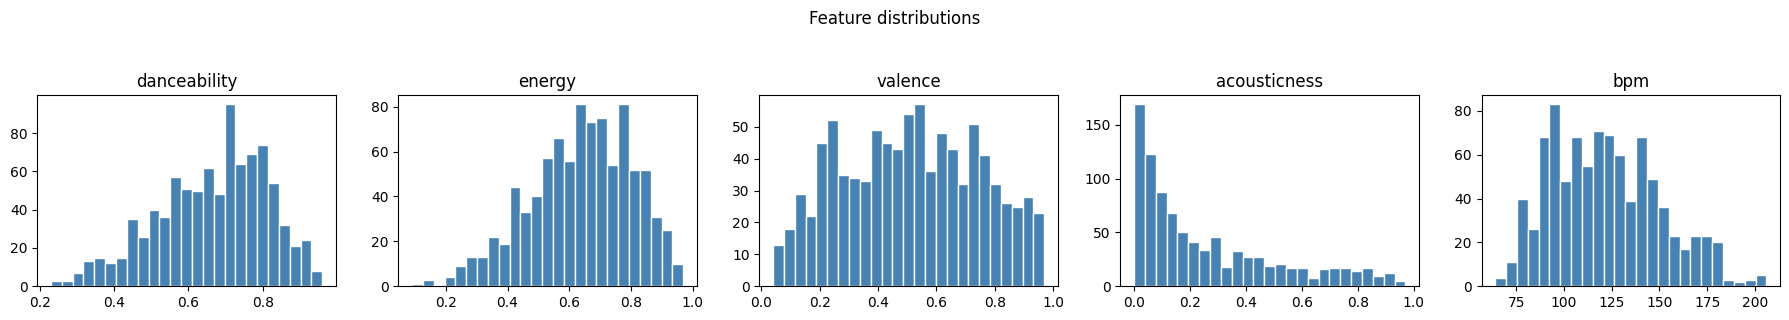

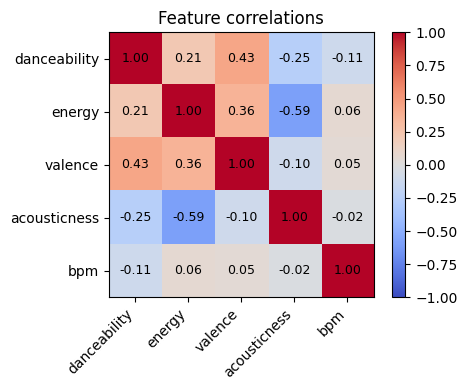

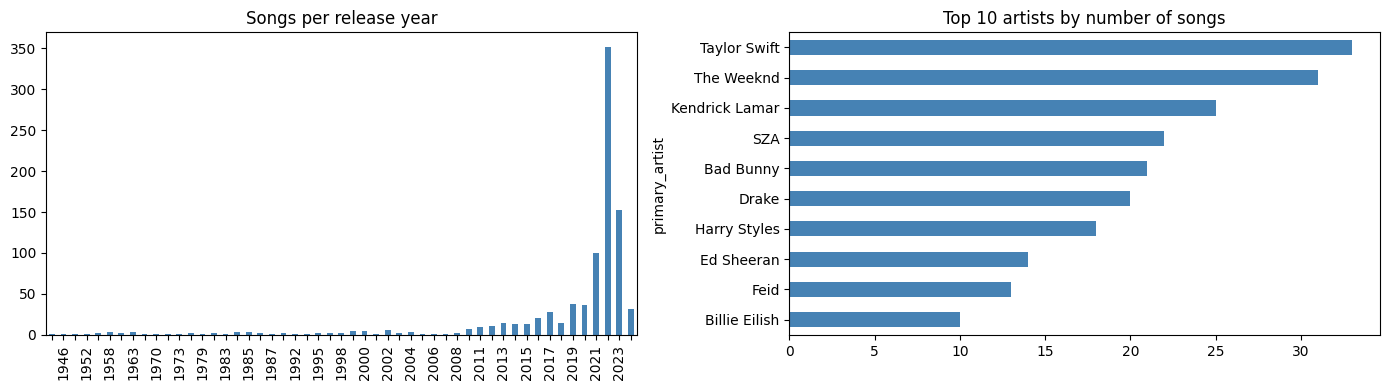

In [23]:
# display feature summary statistics
songs[FEATURES].describe().round(2)

# plot feature distributions
fig, axes = plt.subplots(1, len(FEATURES), figsize=(18, 3))
for ax, col in zip(axes, FEATURES):
    ax.hist(songs[col], bins=25, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.suptitle("Feature distributions", y=1.05)
plt.tight_layout()
plt.show()

# correlation matrix 
corr = songs[FEATURES].corr()

# plot the matrix as a heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURES))); ax.set_yticklabels(FEATURES)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im)
ax.set_title("Feature correlations")
plt.tight_layout()
plt.show()

# plot the number of songs per release year and the top 10 artists by number of songs
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

songs["release_year"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Songs per release year")
axes[0].set_xlabel("")
# keep the x axis readable
for label in axes[0].get_xticklabels()[::2]:
    label.set_visible(False)

songs["primary_artist"].value_counts().head(10).sort_values().plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Top 10 artists by number of songs")

plt.tight_layout()
plt.show()

## Choosing features

| Feature | Used? | Why |
|---|---|---|
| `danceability` | Yes | How suitable the track is for dancing (rhythm stability, beat strength). Captures groove. |
| `energy` | Yes | Intensity and activity (loud, fast, noisy vs. calm). Captures how "intense" a song feels. |
| `valence` | Yes | Musical positivity (high = happy/cheerful, low = sad/tense). Captures mood. |
| `acousticness` | Yes | Confidence the track is acoustic. Separates acoustic/organic songs from electronic/produced ones. |
| `bpm` | Yes | Tempo. Captures pace, which the other features only partly reflect. |
| `release_year` | No (for now) | Reflects era rather than sound. Could be added with a small weight later. |
| `primary_genre` | No | Only ~135 of ~4,800 songs have it. |
| `instrumentalness`, `liveness`, `speechiness`, `key`, `mode` | No | Only available for ~945 songs (from the 2023 source), which would shrink the catalog. |
| Stream counts, playlist counts, popularity | No (as features) | These measure how *big* a song is, not how it *sounds*. Better used later as a filter or tie-breaker (e.g. "similar songs, ranked by popularity"). |

The five chosen features are the ones available for every song in our usable set, and they cover complementary aspects: groove, intensity, mood, texture, and pace.

# Build the model

First we will define what the "distance" between two songs is. Each song is a point in 5-dimensional space, with one axis per feature. Distance is how far apart two songs are in that space. Small distance means similar sound, and 0 means identical features. I used Euclidean distance to start with:
$$distance(A, B) = \sqrt{(danceA - danceB)^2 + (energyA - energyB)^2 + (valenceA - valenceB)^2 + (acousticA - acousticB)^2 + (bpmA - bpmB)^2}$$

In [ ]:
# scale the features first -> this converts each feature into Z-scores so that they are all on the same scale and can be compared directly
scaler = StandardScaler()
X = scaler.fit_transform(songs[FEATURES])

# limitations with standard scaler:
    # 1. it assumes data is normally distributed, which may not be the case for all features
    # 2. it is sensitive to outliers, which can skew the mean and standard deviation
    # 3. all features count equally, which may not be the case for all features (e.g. bpm may be more important than acousticness)

# fit a nearest neighbors model
nn = NearestNeighbors(metric="euclidean") # we can also try the cosine distance metric 
nn.fit(X)

print("Feature matrix shape:", X.shape)

# define a function to get song
def find_song(title, artist=None):
    """
    Return rows of `songs` matching the title (and artist, if given).
    Input: title (str), artist (str, optional)
    Output: DataFrame of matching songs
    """
    mask = songs["title"].str.contains(title, case=False, regex=False)

    # if an artist is specified, filter by that as well 
    if artist:
        mask &= songs["primary_artist"].str.contains(artist, case=False, regex=False)
    return songs[mask]

# define a function to get recommendations
def recommend(title, artist=None, k=10, exclude_same_artist=False):
    """
    Return a list of recommended songs based on the input song.
    Input: title (str), artist (str, optional), k (int, optional), exclude_same_artist (bool, optional)
    Output: DataFrame of recommended songs
    """
    matches = find_song(title, artist)

    # Handle cases where no matches or multiple matches are found
    if matches.empty:
        print(f"No song found matching '{title}'. Try a shorter title or check the spelling.")
        return None

    # Handle cases where multiple matches are found for the same title (common song names, remixes, etc.)
    if len(matches) > 1:
        # If one match is an exact title match, prefer it; otherwise ask the user to be specific.
        exact = matches[matches["title"].str.lower() == title.lower()]
        if len(exact) == 1:
            matches = exact
        else:
            print("Multiple matches found. Add the artist name to narrow it down:")
            print(matches[["title", "primary_artist", "release_year"]].to_string())
            return None

    # Get the index of the seed song
    seed_idx = matches.index[0]
    seed = songs.loc[seed_idx]

    # Ask for extra neighbors so we still have k left after filtering.
    n_ask = min(len(songs), k * 5 + 1)
    dist, idx = nn.kneighbors(X[[seed_idx]], n_neighbors=n_ask) 

    # Filter out the seed song and any remixes/versions by title, and optionally the same artist.
    results = songs.iloc[idx[0]].copy()
    results["distance"] = dist[0].round(3)

    # Filter out the seed song and any remixes/versions by title, and optionally the same artist.
    results = results[results.index != seed_idx]                               # not the seed itself
    results = results[~results["title"].str.contains(seed["title"], case=False, regex=False)]  # remixes / versions
    if exclude_same_artist:
        results = results[results["primary_artist"] != seed["primary_artist"]]

    print(f"Because you picked: {seed['title']} - {seed['primary_artist']} ({seed['release_year']})\n")
    return results.head(k)[["title", "primary_artist", "release_year", "distance"] + FEATURES].reset_index(drop=True)

Feature matrix shape: (914, 5)


## Testing the recommender

In [25]:
recommend("Stay") # case 1, no artist specified, one match found

Because you picked: Stay - The Kid LAROI (2021)



,title,primary_artist,release_year,distance,danceability,energy,valence,acousticness,bpm
0,Plan A,Paulo Londra,2022,0.567,0.58,0.83,0.56,0.05,174.0
1,POLARIS - Remix,Feid,2023,0.609,0.62,0.80,0.55,0.15,170.0
2,Prohibidox,Feid,2022,0.614,0.65,0.80,0.52,0.05,180.0
3,Cruel Summer,Taylor Swift,2019,0.621,0.55,0.72,0.58,0.11,170.0
4,Blinding Lights (Remix),The Weeknd,2020,0.668,0.54,0.80,0.36,0.01,171.0
5,10 Things I Hate About You,Leah Kate,2022,0.704,0.54,0.79,0.45,0.01,154.0
6,Curtains,Ed Sheeran,2023,0.705,0.50,0.76,0.44,0.10,176.0
7,Jimmy Cooks (feat. 21 Savage),Drake,2022,0.783,0.54,0.67,0.40,0.00,163.0
8,Blinding Lights,The Weeknd,2019,0.795,0.50,0.80,0.38,0.00,171.0
9,SNAP,Rosa Linn,2022,0.831,0.56,0.64,0.53,0.11,170.0


In [26]:
recommend("Flowers") # case 2, no artist specified, multiple matches found
recommend("Flowers", "Miley Cyrus") # case 3, artist specified, one match found

Multiple matches found. Add the artist name to narrow it down:
       title        primary_artist  release_year
273  Flowers  Lauren Spencer Smith          2021
274  Flowers           Miley Cyrus          2023
Because you picked: Flowers - Miley Cyrus (2023)



,title,primary_artist,release_year,distance,danceability,energy,valence,acousticness,bpm
0,Leave Before You Love Me (with Jonas Brothers),Marshmello,2021,0.361,0.72,0.72,0.67,0.00,120.0
1,Better Days (NEIKED x Mae Muller x Polo G),NEIKED,2021,0.382,0.72,0.68,0.67,0.00,110.0
2,Permission to Dance,BTS,2021,0.486,0.70,0.74,0.65,0.01,125.0
3,Bones,Imagine Dragons,2021,0.517,0.77,0.72,0.65,0.02,114.0
4,Have You Ever Seen The Rain?,Creedence Clearwater Revival,1968,0.529,0.74,0.70,0.76,0.07,116.0
5,Savage Love,Jawsh 685,2020,0.553,0.76,0.69,0.65,0.01,107.0
6,LOVE DIVE,IVE,2022,0.556,0.70,0.71,0.54,0.00,118.0
7,El Merengue,Marshmello,2023,0.571,0.78,0.68,0.70,0.03,124.0
8,Femininomenon,Chappell Roan,2023,0.632,0.70,0.78,0.68,0.04,116.0
9,Levii's Jeans,Beyoncé,2024,0.634,0.72,0.65,0.72,0.14,106.0


In [27]:
recommend("Flowers", "Miley Cyrus", k=5) # case 4, artist specified, one match found, return 5 recommendations

Because you picked: Flowers - Miley Cyrus (2023)



,title,primary_artist,release_year,distance,danceability,energy,valence,acousticness,bpm
0,Leave Before You Love Me (with Jonas Brothers),Marshmello,2021,0.361,0.72,0.72,0.67,0.00,120.0
1,Better Days (NEIKED x Mae Muller x Polo G),NEIKED,2021,0.382,0.72,0.68,0.67,0.00,110.0
2,Permission to Dance,BTS,2021,0.486,0.70,0.74,0.65,0.01,125.0
3,Bones,Imagine Dragons,2021,0.517,0.77,0.72,0.65,0.02,114.0
4,Have You Ever Seen The Rain?,Creedence Clearwater Revival,1968,0.529,0.74,0.70,0.76,0.07,116.0
